In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

# Bigram Language model
what character comes after character x, very simple and weak language model. But good place to start

In [3]:
# iterate a word with consecutive characters, 2 characters at a time

for w in words[:1]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>


Now that we know what we are doing, progressing ahead

In [4]:
# counter for each pair.
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [5]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

what we are seeing is in our dataset

* n is usually ending character for most names
* a is next most ending character
* a and n appear together the most
* a is most starting character

and so on.

---
# We should keep this in 2D array

* rows: first character
* column: second character
* value: will tell how many times second character follows first character

In [6]:
import torch

#### intro to matrices in torch

In [7]:
a = torch.zeros((3, 5), dtype = torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [8]:
a[2, 3] = 3
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 3, 0]], dtype=torch.int32)

#### representing above bigram dictionary in torch matrix

In [17]:
# we will need 26 * 26 for all alphabets + 2 for start and end char
# so 28 * 28
N = torch.zeros((28, 28), dtype = torch.int32)

# a - z
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27

stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25,
 '<S>': 26,
 '<E>': 27}

In [22]:
# N will have bigram counter

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        N[index1, index2] += 1

#### Finding best way to visualize N

* First we try to print plain N (it's not good)
* Then try to use matplotlib (it's not good either)
* Then we will try something crazy, by inverting the presentation and all. 

In [25]:
# print plain N (it's not good)

N[:10, :10]

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55],
        [ 242,    0,    0,    0,  123,   44,    1,    1,  160,    0],
        [ 330,    3,    0,   19,  334,    1,   25,  360,  190,    3],
        [2244,    8,    2,   24,  674,    2,    2,    1,  729,    9],
        [2445,  110,  509,  440, 1653,  101,  428,   95,   82,   76],
        [1473,    1,    4,    4,  440,    0,    0,   45,  119,    2]],
       dtype=torch.int32)

Matplotlib is building the font cache; this may take a moment.


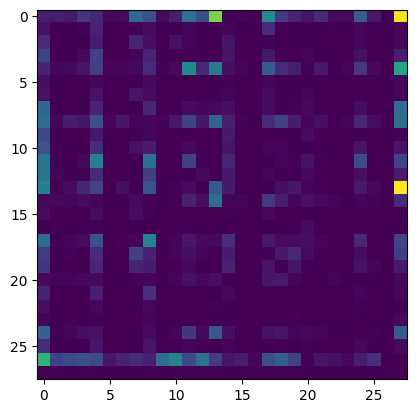

In [12]:
# use matplotlib (it's not good either)

import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [16]:
# inverting the presentation
# if stoi mapped character to index
# itos in inverted s

itos = {i:s for s, i in stoi.items()}
itos

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: '<S>',
 27: '<E>'}

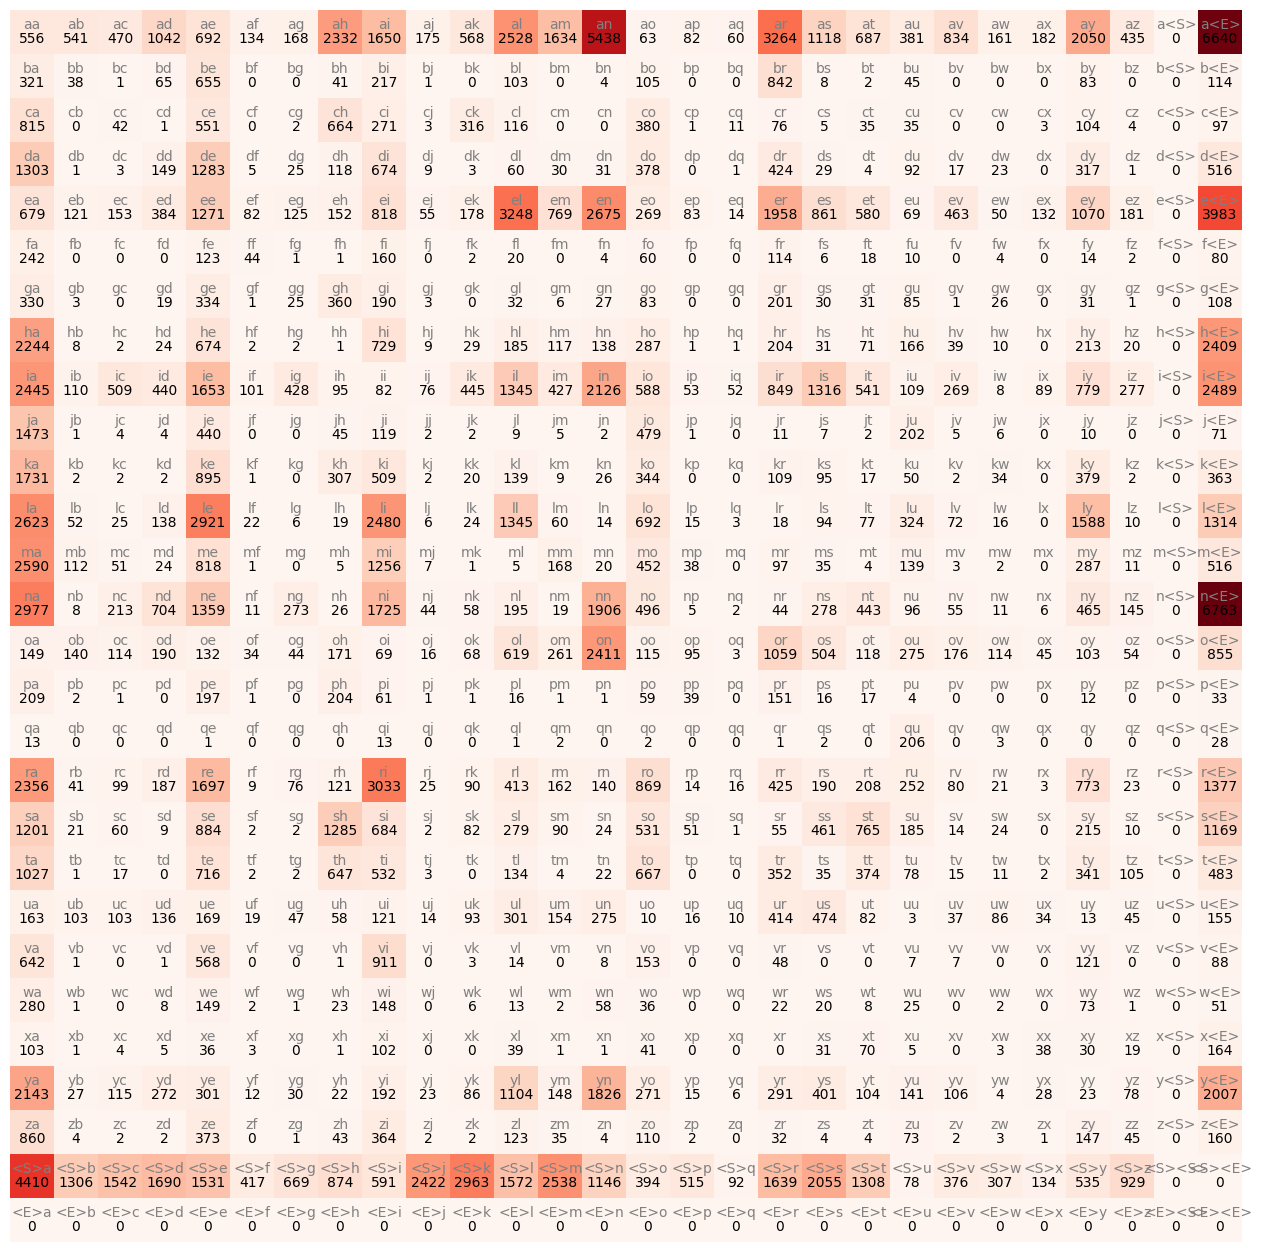

In [35]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize = (16, 16))
# This prints the whole matrix with color shades (weighed by count)
plt.imshow(N, cmap = 'Reds')

# iterate and add count and bigram
for i in range(28):
    for j in range(28):
        # bigram
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = 'gray')
        # count (N[i, j].item() is count)
        plt.text(j, i, N[i, j].item(), ha = "center", va = "top", color = 'black')
plt.axis('off');

#### scrutinizing the matrix

* Last row is entirely 0
* last column is entirely 0

I think we can make it more efficient. Will move to new notebook.